In [1]:
#import libraries
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn import datasets

In [2]:
#load the dataset
X,y_true=make_blobs(n_samples=300,centers=4, cluster_std=0.50, random_state=0)

['y', 'b', 'g', 'r']


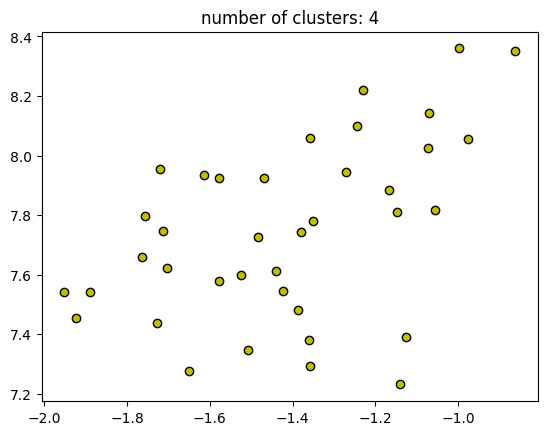

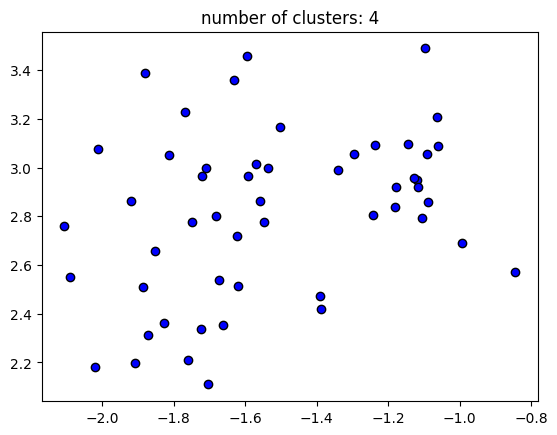

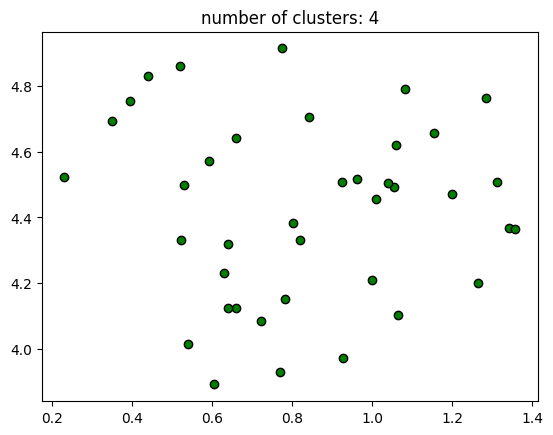

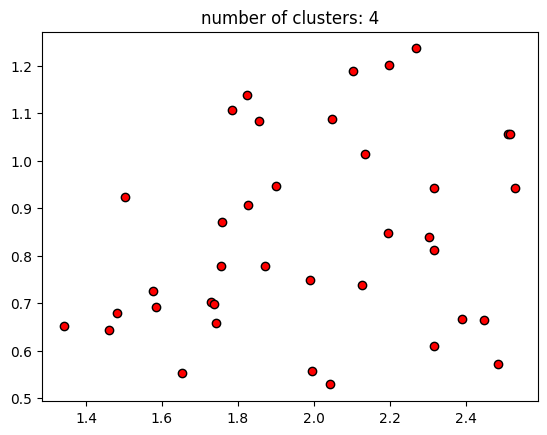

In [3]:
# Modelling the data using DBSCAN
db=DBSCAN(eps=0.3,min_samples=10).fit(X)
core_sample_mask=np.zeros_like(db.labels_,dtype=bool)
core_sample_mask[db.core_sample_indices_]=True
labels=db.labels_

# Number of clusters in labels, ignoring noise
# if present
n_clusters_ =len(set(labels)) -(1 if -1 in labels else 0)
#plot result
#Black removed and is used for noise instead
unique_labels =set(labels)
colors = ['y', 'b', 'g', 'r']
print(colors)
for k, col in zip(unique_labels, colors):
    if k == -1:
        #Black used for noise.
        col = 'k'
    class_member_mask = (labels == k)
    xy = X[class_member_mask & core_sample_mask]
    plt.plot(xy[:,0], xy[:,1], 'o',
             markerfacecolor=col, 
             markeredgecolor='k',
             markersize=6)
    xy = X[class_member_mask & ~core_sample_mask]
    plt.plot(xy[:,0], xy[:,1], 'o',
             markerfacecolor=col, 
             markeredgecolor='k',
             markersize=6)
    plt.title('number of clusters: %d'
              %n_clusters_)
    plt.show()

In [4]:
# evaluation metrics
import sklearn.metrics as metrics
from sklearn.metrics.cluster import adjusted_rand_score
sc = metrics.silhouette_score(X, labels)
print("Silhouette Coefficient:%0.2f" % sc)
ari = adjusted_rand_score(y_true, labels)
print("Adjusted Rand Index: %0.2f" % ari)

Silhouette Coefficient:0.13
Adjusted Rand Index: 0.31


# DBSCAN vs. K-Means 

In [5]:
# Visual comparison 
# To illustrate these differences, let's apply both algorithms to our moon-shaped dataset

from sklearn.cluster import KMeans 
# DBSCAN clustering 
dbscan = DBSCAN(eps=0.15, min_samples=5) 
dbscan_labels = dbscan.fit_predict(X)

In [6]:
# K-Means clustering 
kmeans = KMeans(n_clusters=2, random_state=42) 
kmeans_labels = kmeans.fit_predict(X)

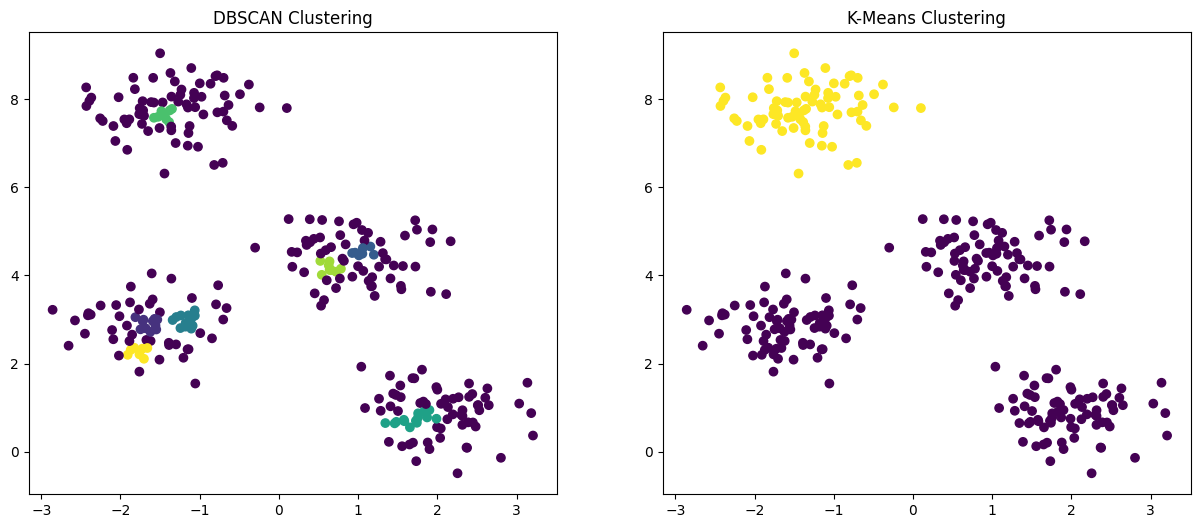

In [8]:
# Visualize the results 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6)) 
ax1.scatter(X[:, 0], X[:, 1], c=dbscan_labels, cmap='viridis') 
ax1.set_title('DBSCAN Clustering') 
ax2.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis') 
ax2.set_title('K-Means Clustering') 
plt.show()

# Implementing DBSCAN in Python 

In [9]:
#use the Make Moons dataset to demonstrate the process. 
#Importing Libraries 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_moons 
from sklearn.cluster import DBSCAN 
from sklearn.neighbors import NearestNeighbors 

In [10]:
# Generating sample data 
X, _ = make_moons(n_samples=200, noise=0.05, random_state=42) 
#The make_moons function generates a binary classification dataset that 
# resembles two interleaving half moons. In our case: 
# • We create 200 samples (n_samples=200) 
# • We add a small amount of Gaussian noise (noise=0.05) to make the 
# dataset more realistic 
# • We set random_state=42 for reproducibility

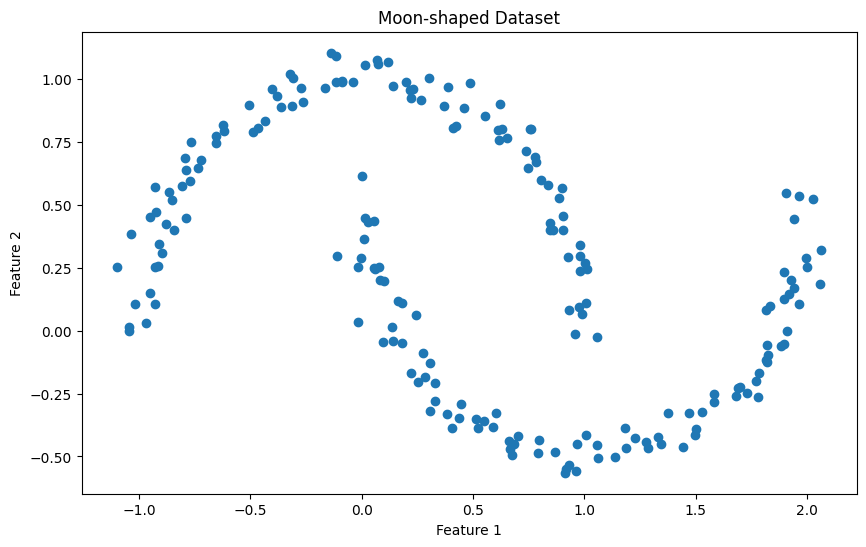

In [11]:
#Let's visualize this dataset to better understand its structure: 
# Visualize the dataset 
plt.figure(figsize=(10, 6)) 
plt.scatter(X[:, 0], X[:, 1]) 
plt.title('Moon-shaped Dataset') 
plt.xlabel('Feature 1') 
plt.ylabel('Feature 2') 
plt.show()

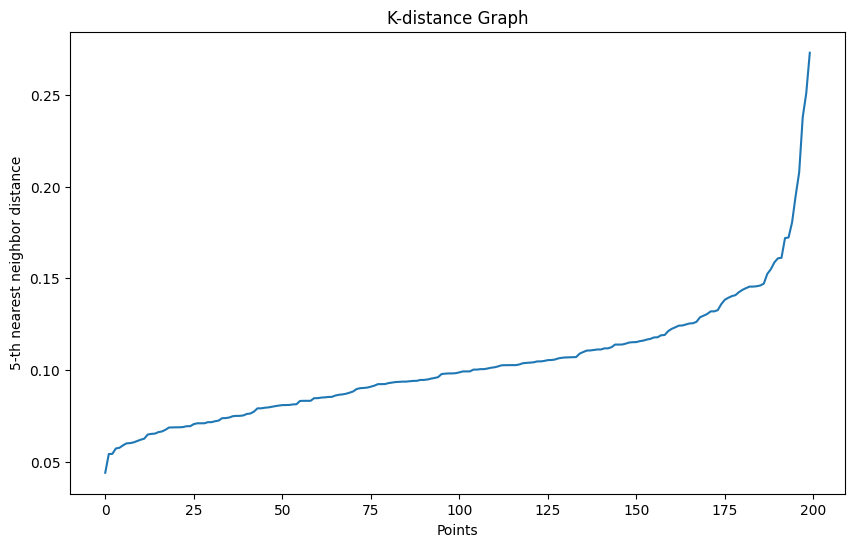

In [12]:
#Determining the epsilon parameter 
# We use the k-distance graph method to help choose an appropriate epsilon 
# value: 
# 1. We define a function plot_k_distance_graph that calculates the distance 
# to the k-th nearest neighbor for each point. 
# 2. The distances are sorted and plotted. 
# 3. We look for an "elbow" in the resulting graph to choose epsilon. 
# Function to plot k-distance graph 
def plot_k_distance_graph(X, k): 
    neigh = NearestNeighbors(n_neighbors=k) 
    neigh.fit(X) 
    distances, _ = neigh.kneighbors(X) 
    distances = np.sort(distances[:, k-1]) 
    plt.figure(figsize=(10, 6)) 
    plt.plot(distances) 
    plt.xlabel('Points') 
    plt.ylabel(f'{k}-th nearest neighbor distance') 
    plt.title('K-distance Graph') 
    plt.show() 
# Plot k-distance graph 
plot_k_distance_graph(X, k=5) 

In [13]:
#Performing DBSCAN clustering 
#We use scikit-learn's DBSCAN implementation: 
# 1. We set epsilon=0.15 based on our k-distance graph. 
# 2. We set min_samples=5 (2 * num_features, as our data is 2D). 
# 3. We fit the model to our data and predict the clusters. 
# Perform DBSCAN clustering 
epsilon = 0.15  # Chosen based on k-distance graph 
min_samples = 5  # 2 * num_features (2D data) 
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples) 
clusters = dbscan.fit_predict(X)

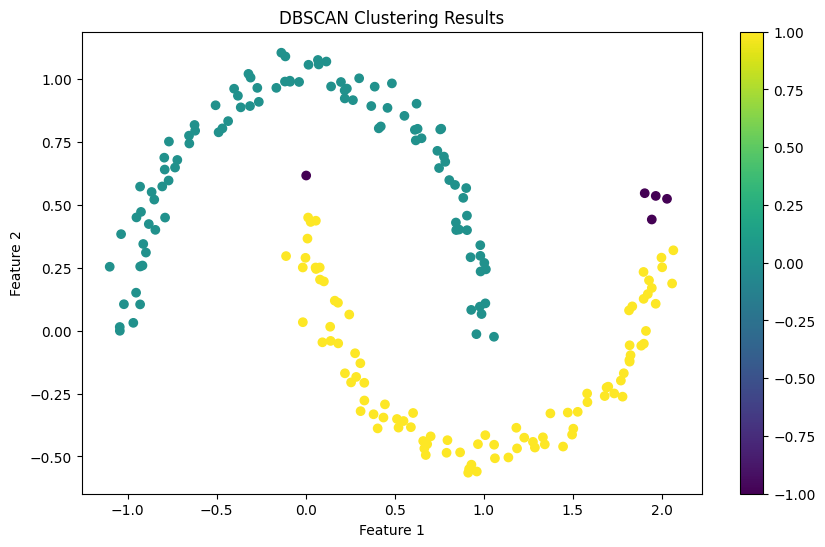

In [14]:
#Visualizing the results 
plt.figure(figsize=(10, 6)) 
scatter = plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis') 
plt.colorbar(scatter) 
plt.title('DBSCAN Clustering Results') 
plt.xlabel('Feature 1') 
plt.ylabel('Feature 2') 
plt.show()

In [15]:
#Interpreting the results 
# Finally, we print out the number of clusters found and the number of points 
# classified as noise. This gives us a quick summary of the clustering results. 
# Print number of clusters and noise points 
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0) 
n_noise = list(clusters).count(-1) 
print(f'Number of clusters: {n_clusters}') 
print(f'Number of noise points: {n_noise}')

Number of clusters: 2
Number of noise points: 5
